# Exploratory Data Analysis & Preprocessing Strategy

1. Matrix Auditing (Sparsity & Dimensionality)
2. Distributions
3. Conversion Funnel
4. Temporal Dynamics & Validation Strategy
5. Metadata Enrichment & Taxonomy Alignment
6. Preprocessing & Filtering Rules (Pruning Criteria)

In [1]:
import datetime
import pathlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

base_dir = pathlib.Path().resolve().parent
data_dir = pathlib.posixpath.join(base_dir, "data")
figs_dir = pathlib.posixpath.join(base_dir, "docs", "figures")

# for file_path in sorted(pathlib.os.listdir(data_dir)):
#     print(file_path)

events_file_path           = pathlib.posixpath.join(data_dir, "events.csv")
category_tree_path         = pathlib.posixpath.join(data_dir, "category_tree.csv")
item_properties_part1_path = pathlib.posixpath.join(data_dir, "item_properties_part1.csv")
item_properties_part2_path = pathlib.posixpath.join(data_dir, "item_properties_part1.csv")


def figure_path(figure_name: str) -> str:
    """Prepend figures directory to `figure_name`."""
    return pathlib.posixpath.join(figs_dir, figure_name)


df_events          = pl.scan_csv(events_file_path)
df_category_tree   = pl.scan_csv(category_tree_path)
df_item_properties = pl.concat([
    pl.scan_csv(item_properties_part1_path),
    pl.scan_csv(item_properties_part2_path),
])

## 1. Matrix Auditing (Sparsity & Dimensionality)

In [2]:
print("================================================ EVENTS ================================================")
print(df_events.describe())
print("============================================ CATEGORY TREE =============================================")
print(df_category_tree.describe())
print("============================================== ITEM PPTS ===============================================")
print(df_item_properties.describe())
print("========================================================================================================")

================================================ EVENTS ================================================
shape: (9, 6)
┌────────────┬────────────┬───────────────┬───────────┬───────────────┬───────────────┐
│ statistic  ┆ timestamp  ┆ visitorid     ┆ event     ┆ itemid        ┆ transactionid │
│ ---        ┆ ---        ┆ ---           ┆ ---       ┆ ---           ┆ ---           │
│ str        ┆ f64        ┆ f64           ┆ str       ┆ f64           ┆ str           │
╞════════════╪════════════╪═══════════════╪═══════════╪═══════════════╪═══════════════╡
│ count      ┆ 2.756101e6 ┆ 2.756101e6    ┆ 2756101   ┆ 2.756101e6    ┆ 22457         │
│ null_count ┆ 0.0        ┆ 0.0           ┆ 0         ┆ 0.0           ┆ 2733644       │
│ mean       ┆ 1.4364e12  ┆ 701922.883229 ┆ null      ┆ 234922.478375 ┆ null          │
│ std        ┆ 3.3663e9   ┆ 405687.520809 ┆ null      ┆ 134195.425214 ┆ null          │
│ min        ┆ 1.4306e12  ┆ 0.0           ┆ addtocart ┆ 3.0           ┆ 0             │
│

In [3]:
metrics = df_events.select([
    pl.len().alias("total_events"),
    pl.col("visitorid").n_unique().alias("unique_users"),
    pl.col("itemid").n_unique().alias("unique_items"),
]).collect().to_dicts()[0]

total_events = metrics["total_events"]
n_users = metrics["unique_users"]
n_items = metrics["unique_items"]

sparsity = 1.0 - (total_events / (n_users * n_items))

print("=================== MATRIX AUDIT ===================")
print(f"Total Interaction Events: {total_events:,}")
print(f"Unique Users (Visitors):  {n_users:,}")
print(f"Unique Items:             {n_items:,}")
print(f"Matrix Dimensions:        {n_users:,} x {n_items:,}")
print(f"Sparsity Index:           {sparsity:.8f} ({sparsity * 100:.6f}%)")
print("====================================================")

=================== MATRIX AUDIT ===================
Total Interaction Events: 2,756,101
Unique Users (Visitors):  1,407,580
Unique Items:             235,061
Matrix Dimensions:        1,407,580 x 235,061
Sparsity Index:           0.99999167 (99.999167%)


## 2. Distributions

### 2.1. User Engagement Decay

In [4]:
user_activity = (
    df_events.group_by("visitorid")
    .agg(pl.len().alias("interactions_count"))
    .collect()
)
# user interactions counter
interactions_count = user_activity["interactions_count"].to_numpy()
# users with only one interaction
unique_interactions = (interactions_count == 1).sum()
# unique users with 1 or more interactions
unique_users = len(interactions_count)

print("================ USER ENGAGEMENT METRICS ================")
print(f"┍ Total Unique Users:             {unique_users:,}")
print(f"┝ Max Interactions by one User:   {interactions_count.max():,}")
print(f"┝ Mean Interactions per User:     {interactions_count.mean():.2f}")
print(f"┝ Median Interactions per User:   {np.median(interactions_count):.2f}")
print(f"┕ Users with exactly 1 Event:     {unique_interactions:,} ({unique_interactions / unique_users * 100:.2f}%)")
# print("=========================================================")

# event_types = sorted(df_events.select(pl.col("event")).unique().collect().to_numpy().reshape(1, -1)[0])
event_types = ["view", "addtocart", "transaction"]
event_metrics = {}

for event in event_types:
    event_user_activity = (
        df_events.filter(pl.col("event") == event)
        .group_by("visitorid")
        .agg(pl.len().alias("interaction_count"))
        .collect()
    )
    event_interactions_count = event_user_activity["interaction_count"].to_numpy()
    event_unique_users = len(event_interactions_count)
    event_unique_interactions = (event_interactions_count == 1).sum()
    event_metrics[event] = {
        "interactions_count": event_interactions_count,
        "unique_users": event_unique_users,
        "unique_interactions": event_unique_interactions,
    }

    sec_header = f"▶ {event} events"
    print(sec_header)
    print(f"  ┍ Total Unique Users:           {event_unique_users:,}")
    print(f"  ┝ Max Interactions by one User: {event_interactions_count.max():,}")
    print(f"  ┝ Mean Interactions per User:   {event_interactions_count.mean():.2f}")
    print(f"  ┝ Median Interactions per User: {np.median(event_interactions_count):.2f}")
    print(f"  ┕ Users with exactly 1 Event:   {event_unique_interactions:,} ({event_unique_interactions / event_unique_users * 100:.2f}% of {event} and {event_unique_interactions / unique_users * 100:.2f}% total)")


================ USER ENGAGEMENT METRICS ================
┍ Total Unique Users:             1,407,580
┝ Max Interactions by one User:   7,757
┝ Mean Interactions per User:     1.96
┝ Median Interactions per User:   1.00
┕ Users with exactly 1 Event:     1,001,560 (71.15%)
▶ view events
  ┍ Total Unique Users:           1,404,179
  ┝ Max Interactions by one User: 6,479
  ┝ Mean Interactions per User:   1.90
  ┝ Median Interactions per User: 1.00
  ┕ Users with exactly 1 Event:   1,007,730 (71.77% of view and 71.59% total)
▶ addtocart events
  ┍ Total Unique Users:           37,722
  ┝ Max Interactions by one User: 719
  ┝ Mean Interactions per User:   1.84
  ┝ Median Interactions per User: 1.00
  ┕ Users with exactly 1 Event:   28,647 (75.94% of addtocart and 2.04% total)
▶ transaction events
  ┍ Total Unique Users:           11,719
  ┝ Max Interactions by one User: 559
  ┝ Mean Interactions per User:   1.92
  ┝ Median Interactions per User: 1.00
  ┕ Users with exactly 1 Event:   9,143 

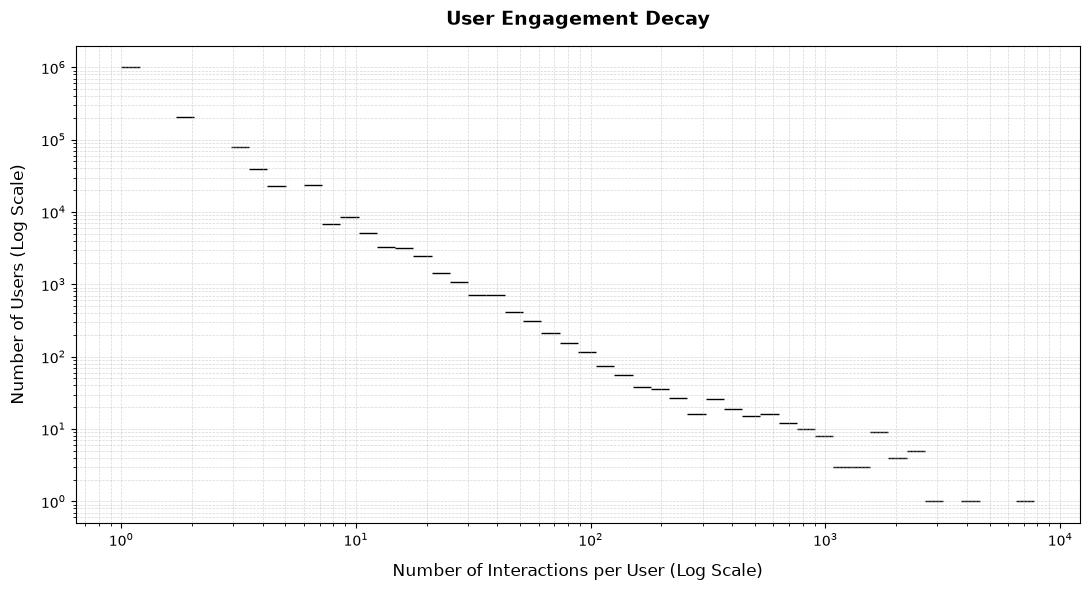

In [5]:
plt.figure(figsize=(11, 6))
sns.histplot(
    interactions_count,
    bins=50,
    log_scale=(True, True),
    kde=False,
    color="royalblue",
    edgecolor="black",
    alpha=0.75
)
plt.title("User Engagement Decay", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Number of Interactions per User (Log Scale)", fontsize=12, labelpad=10)
plt.ylabel("Number of Users (Log Scale)", fontsize=12, labelpad=10)
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(figure_path("user_engagement_decay.png"), dpi=150, bbox_inches="tight")
plt.show()

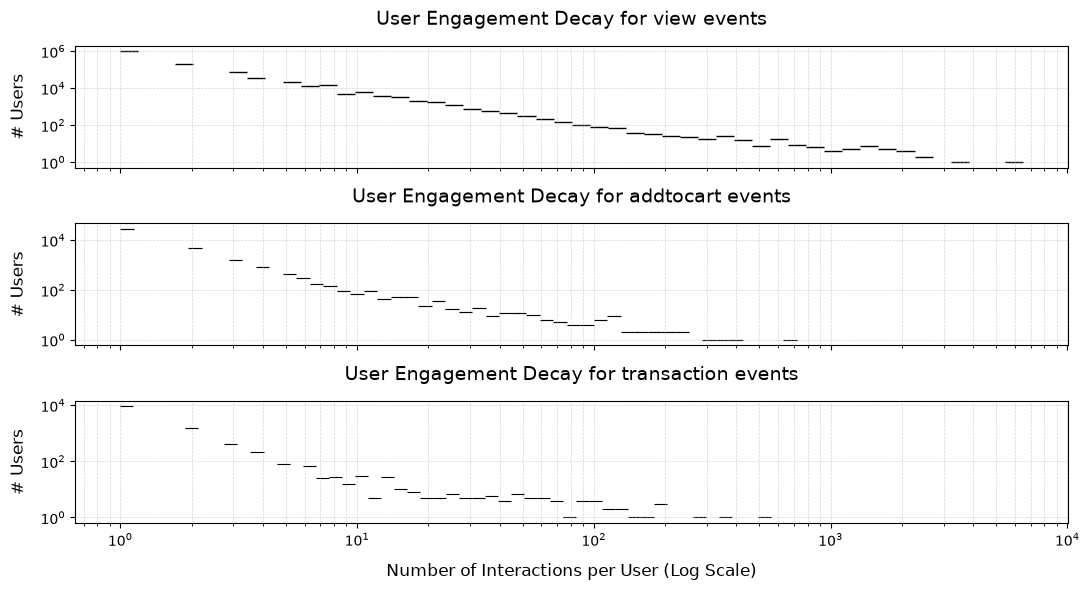

In [6]:
fig, axs = plt.subplots(3, 1, figsize=(11, 6), sharex=True)

for ax, event in zip(axs, event_types):
    sns.histplot(
        event_metrics[event]["interactions_count"],
        bins=50,
        log_scale=(True, True),
        kde=False,
        color="royalblue",
        edgecolor="black",
        alpha=0.75,
        label=event,
        ax=ax,
    )
    ax.set_title(f"User Engagement Decay for {event} events", fontsize=14, pad=15)
    ax.set_xlabel("Number of Interactions per User (Log Scale)", fontsize=12, labelpad=10)
    ax.set_ylabel("# Users", fontsize=12, labelpad=10)
    ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(figure_path("user_event_engagement_decay.png"), dpi=150, bbox_inches="tight")
plt.show()

In [7]:
print("=========== # USERS WITH UP TO N INTERACTIONS ===========")

for i in [1, 10, 100, 1000]:
    interactions = (interactions_count <= i).sum()
    print(f"Users with up to {i:4d} interaction: {interactions:,} ({interactions / unique_users * 100:.2f}%)")

print("=========================================================")

=========== # USERS WITH UP TO N INTERACTIONS ===========
Users with up to    1 interaction: 1,001,560 (71.15%)
Users with up to   10 interaction: 1,387,998 (98.61%)
Users with up to  100 interaction: 1,407,172 (99.97%)
Users with up to 1000 interaction: 1,407,550 (100.00%)


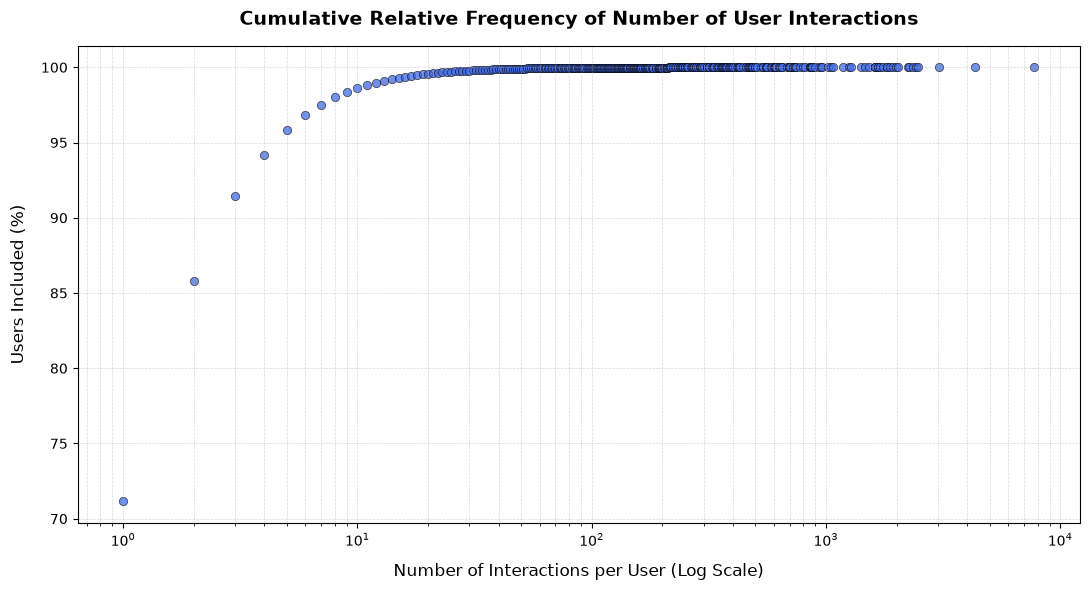

In [8]:
number_of_interactions, users_counts = np.unique(interactions_count, return_counts=True)
cumulative_relative_freq = 100 * np.cumsum(users_counts) / unique_users

plt.figure(figsize=(11, 6))

sns.scatterplot(
    x=number_of_interactions,
    y=cumulative_relative_freq,
    color="royalblue",
    edgecolor="black",
    alpha=0.75
)

plt.title("Cumulative Relative Frequency of Number of User Interactions", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Number of Interactions per User (Log Scale)", fontsize=12, labelpad=10)
plt.ylabel("Users Included (%)", fontsize=12, labelpad=10)
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)
plt.xscale("log")

plt.tight_layout()
plt.savefig(figure_path("crf_user_interactions.png"), dpi=150, bbox_inches="tight")
plt.show()

In [9]:
percentiles = [90, 95, 99, 99.9, 99.99, 99.999]
results = {p: user_activity["interactions_count"].quantile(p / 100) for p in percentiles}

print("================ BOT THRESHOLDING AUDIT ================")
for p, val in results.items():
    print(f"{p:>5}th Percentile: {int(val):>5} interactions")
print(f"\nMaximum Interactions: {user_activity["interactions_count"].max():>5} interactions")
print("========================================================")

p99_9 = results[99.9]
p99_99 = results[99.99]
p99_999 = results[99.999]

print(f"Insight: 99.9% of users have <= {int(p99_9)} interactions.")
print(f"Insight: Only 0.01% of users (approx. {int(unique_users * 0.0001)}) have more than {int(p99_99)}.")
print(f"Insight: Only 0.001% of users (approx. {int(unique_users * 0.00001)}) have more than {int(p99_999)}.")

================ BOT THRESHOLDING AUDIT ================
   90th Percentile:     3 interactions
   95th Percentile:     5 interactions
   99th Percentile:    13 interactions
 99.9th Percentile:    47 interactions
99.99th Percentile:   279 interactions
99.999th Percentile:  1752 interactions

Maximum Interactions:  7757 interactions
Insight: 99.9% of users have <= 47 interactions.
Insight: Only 0.01% of users (approx. 140) have more than 279.
Insight: Only 0.001% of users (approx. 14) have more than 1752.


In [10]:
between_3_and_1000 = ((2 < interactions_count) & (interactions_count < 1000)).sum()
between_5_and_1000 = ((5 < interactions_count) & (interactions_count < 1000)).sum()

print("========== PRUNING USERS BASED ON MIN AND MAX INTERACTIONS ==========")
print(f"Total Unique Users:                                 {unique_users:,}")
print(f"Users with at least 3 and less than 1,000 events:   {between_3_and_1000:,} ({between_3_and_1000 / unique_users * 100:.2f}%)")
print(f"Users with at least 5 and less than 1,000 events:   {between_5_and_1000:,} ({between_5_and_1000 / unique_users * 100:.2f}%)")
print("=====================================================================")

========== PRUNING USERS BASED ON MIN AND MAX INTERACTIONS ==========
Total Unique Users:                                 1,407,580
Users with at least 3 and less than 1,000 events:   199,998 (14.21%)
Users with at least 5 and less than 1,000 events:   58,623 (4.16%)


### 2.2. Item Popularity Dominance

In [11]:
item_activity = (
    df_events.group_by("itemid")
    .agg(pl.len().alias("interactions_count"))
    .collect()
)
# item interactions counter
item_interactions_count = item_activity["interactions_count"].to_numpy()
# items with only one interaction
item_unique_interactions = (item_interactions_count == 1).sum()
# unique items with 1 or more interactions
unique_items = len(item_interactions_count)

print("================ ITEM ENGAGEMENT METRICS ================")
print(f"┍ Total Unique Items:             {unique_items:,}")
print(f"┝ Max Interactions by one Item:   {item_interactions_count.max():,}")
print(f"┝ Mean Interactions per Item:     {item_interactions_count.mean():.2f}")
print(f"┝ Median Interactions per Item:   {np.median(item_interactions_count):.2f}")
print(f"┕ Items with exactly 1 Event:     {item_unique_interactions:,} ({item_unique_interactions / unique_items * 100:.2f}%)")
# print("=========================================================")

item_event_metrics = {}

for event in event_types:
    event_item_activity = (
        df_events.filter(pl.col("event") == event)
        .group_by("itemid")
        .agg(pl.len().alias("interaction_count"))
        .collect()
    )
    event_interactions_count = event_item_activity["interaction_count"].to_numpy()
    event_unique_items = len(event_interactions_count)
    event_unique_interactions = (event_interactions_count == 1).sum()
    item_event_metrics[event] = {
        "interactions_count": event_interactions_count,
        "unique_items": event_unique_items,
        "unique_interactions": event_unique_interactions,
    }

    sec_header = f"▶ {event} events"
    print(sec_header)
    print(f"  ┍ Total Unique Items:           {event_unique_items:,}")
    print(f"  ┝ Max Interactions by one Item: {event_interactions_count.max():,}")
    print(f"  ┝ Mean Interactions per Item:   {event_interactions_count.mean():.2f}")
    print(f"  ┝ Median Interactions per Item: {np.median(event_interactions_count):.2f}")
    print(f"  ┕ Items with exactly 1 Event:   {event_unique_interactions:,} ({event_unique_interactions / event_unique_items * 100:.2f}% of {event} and {event_unique_interactions / unique_items * 100:.2f}% total)")


================ ITEM ENGAGEMENT METRICS ================
┍ Total Unique Items:             235,061
┝ Max Interactions by one Item:   3,412
┝ Mean Interactions per Item:     11.73
┝ Median Interactions per Item:   3.00
┕ Items with exactly 1 Event:     73,609 (31.31%)
▶ view events
  ┍ Total Unique Items:           234,838
  ┝ Max Interactions by one Item: 3,410
  ┝ Mean Interactions per Item:   11.35
  ┝ Median Interactions per Item: 3.00
  ┕ Items with exactly 1 Event:   73,793 (31.42% of view and 31.39% total)
▶ addtocart events
  ┍ Total Unique Items:           23,903
  ┝ Max Interactions by one Item: 306
  ┝ Mean Interactions per Item:   2.90
  ┝ Median Interactions per Item: 2.00
  ┕ Items with exactly 1 Event:   11,418 (47.77% of addtocart and 4.86% total)
▶ transaction events
  ┍ Total Unique Items:           12,025
  ┝ Max Interactions by one Item: 133
  ┝ Mean Interactions per Item:   1.87
  ┝ Median Interactions per Item: 1.00
  ┕ Items with exactly 1 Event:   7,714 (64.15% 

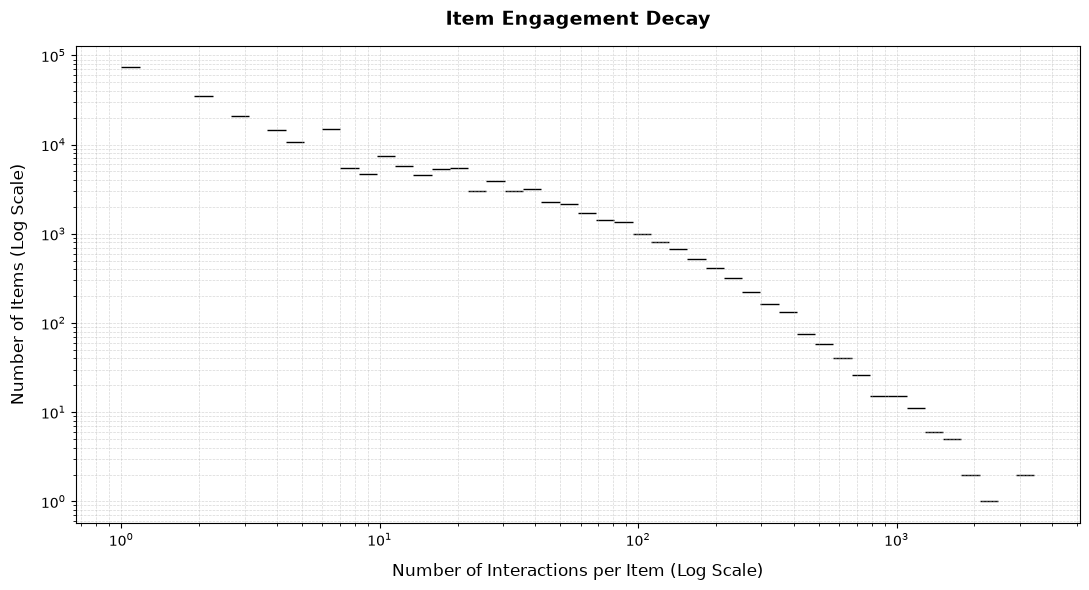

In [12]:
plt.figure(figsize=(11, 6))
sns.histplot(
    item_interactions_count,
    bins=50,
    log_scale=(True, True),
    kde=False,
    color="royalblue",
    edgecolor="black",
    alpha=0.75
)
plt.title("Item Engagement Decay", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Number of Interactions per Item (Log Scale)", fontsize=12, labelpad=10)
plt.ylabel("Number of Items (Log Scale)", fontsize=12, labelpad=10)
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(figure_path("item_engagement_decay.png"), dpi=150, bbox_inches="tight")
plt.show()

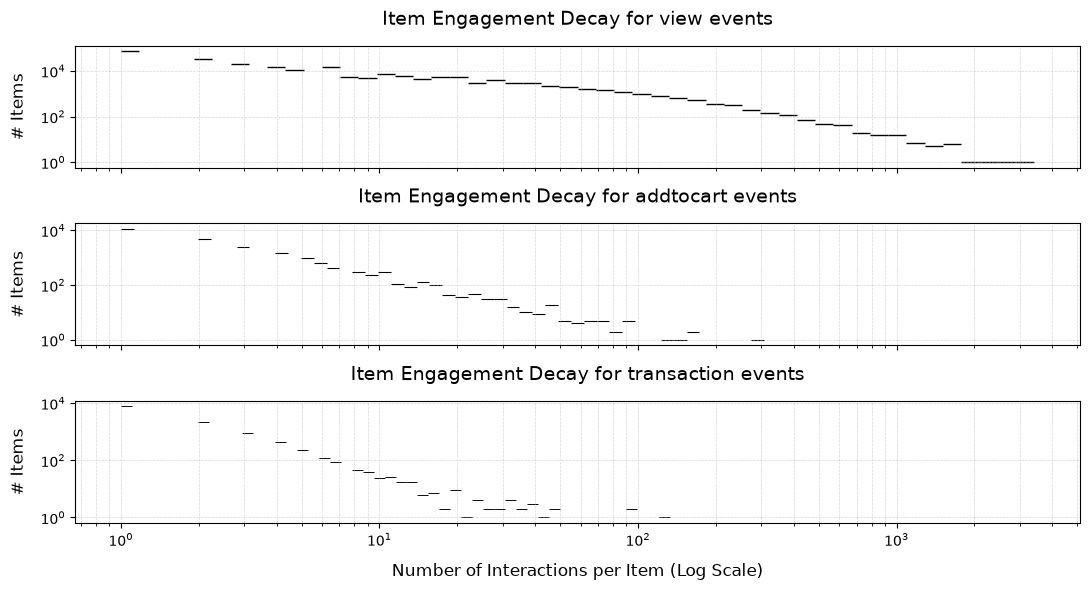

In [13]:
fig, axs = plt.subplots(3, 1, figsize=(11, 6), sharex=True)

for ax, event in zip(axs, event_types):
    sns.histplot(
        item_event_metrics[event]["interactions_count"],
        bins=50,
        log_scale=(True, True),
        kde=False,
        color="royalblue",
        edgecolor="black",
        alpha=0.75,
        label=event,
        ax=ax,
    )
    ax.set_title(f"Item Engagement Decay for {event} events", fontsize=14, pad=15)
    ax.set_xlabel("Number of Interactions per Item (Log Scale)", fontsize=12, labelpad=10)
    ax.set_ylabel("# Items", fontsize=12, labelpad=10)
    ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(figure_path("item_event_engagement_decay.png"), dpi=150, bbox_inches="tight")
plt.show()

In [14]:
print("=========== # ITEM WITH UP TO N INTERACTIONS ===========")

for i in [1, 10, 100, 1000]:
    interactions = (item_interactions_count <= i).sum()
    print(f"Items with up to {i:4d} interactions: {interactions:,} ({interactions / unique_items * 100:.2f}%)")

print("=========================================================")

=========== # ITEM WITH UP TO N INTERACTIONS ===========
Items with up to    1 interactions: 73,609 (31.31%)
Items with up to   10 interactions: 183,995 (78.28%)
Items with up to  100 interactions: 230,894 (98.23%)
Items with up to 1000 interactions: 235,025 (99.98%)


In [15]:
print("=========== # ITEM WITH AT LEAST N INTERACTIONS ===========")

for i in [1, 3, 5, 10, 100, 1000]:
    interactions = (item_interactions_count >= i).sum()
    print(f"Items with at least {i:4d} interactions: {interactions:,} ({interactions / unique_items * 100:.2f}%)")

print("=========================================================")

=========== # ITEM WITH AT LEAST N INTERACTIONS ===========
Items with at least    1 interactions: 235,061 (100.00%)
Items with at least    3 interactions: 126,623 (53.87%)
Items with at least    5 interactions: 90,948 (38.69%)
Items with at least   10 interactions: 55,128 (23.45%)
Items with at least  100 interactions: 4,221 (1.80%)
Items with at least 1000 interactions: 36 (0.02%)


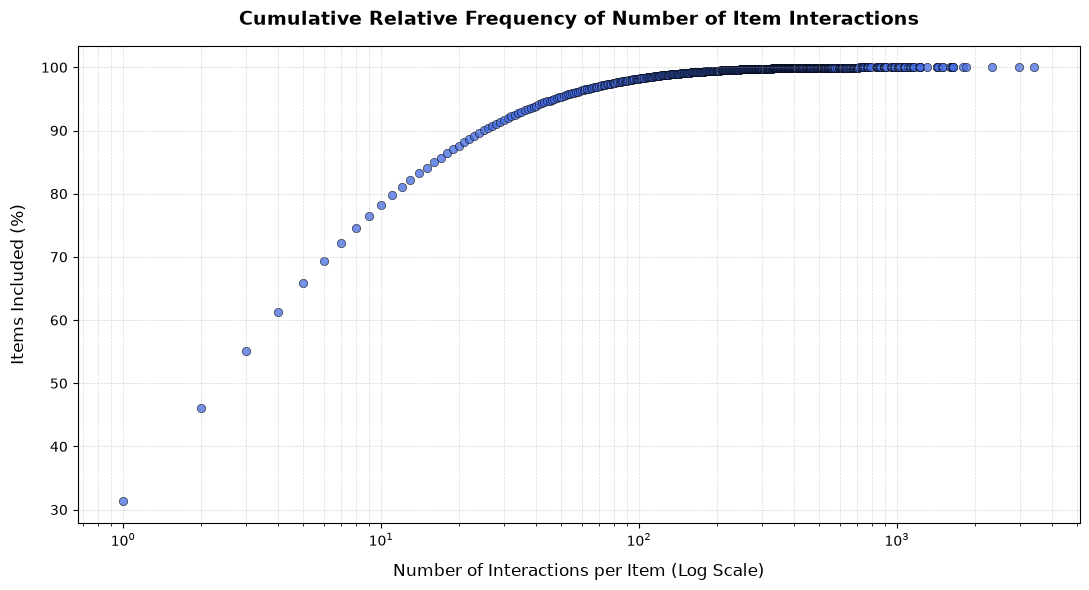

In [16]:
number_of_interactions, items_counts = np.unique(item_interactions_count, return_counts=True)
cumulative_relative_freq = 100 * np.cumsum(items_counts) / unique_items

plt.figure(figsize=(11, 6))

sns.scatterplot(
    x=number_of_interactions,
    y=cumulative_relative_freq,
    color="royalblue",
    edgecolor="black",
    alpha=0.75
)

plt.title("Cumulative Relative Frequency of Number of Item Interactions", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Number of Interactions per Item (Log Scale)", fontsize=12, labelpad=10)
plt.ylabel("Items Included (%)", fontsize=12, labelpad=10)
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)
plt.xscale("log")

plt.tight_layout()
plt.savefig(figure_path("crf_item_interactions.png"), dpi=150, bbox_inches="tight")
plt.show()

### 2.3. Key Diagnostic Insights

1. The **Median of 1.00** and **1,001,560 (71.15%) users with exactly 1 interaction** reveal that it will not be possible to learn high-quality latent preference (user embeddings) from most interactions.
2. The maximum interaction count for a single visitor is **7,757 events**. It can be an indicative of automated web crawlers or scrapers.
3. There are **199,998 (14.21%) users** with at least 3 and less than 1,000 interactions.
4. A **Median of 3.00** indicates that more than half of the catalog has multiple interactions. This is a much better distribution than the user-side (Median 1.00), allowing the model to learn relationships between different users based on shared item interests.
5. **73,609 (31.31%) items** have only one interaction.
6. **126,623 (53.87%) items** have at least 3 interactions.
7. Items with 1,000+ interactions can indicate non-organic strategies or they can really be items that went viral.

**Architectural and Algorithmic Decisions**

In production, it is expected that more than half (**~70%**) of the requests will involve users with no meaningful historical profile (zero or one previous interaction). 

Three models will be used:
- **Tier 1:** the more robust PyTorch embedding based model for users with sufficient history.
- **Tier 2:** a similarity based model for users with 1 or 2 previous interactions.
- **Tier 3:** a popularity based model for users with no previous interactions.

## 3. Implicit Feedback Funnel

### 3.1. User-Item-Level Chronological Funnel

In [17]:
funnel_steps = (
    df_events.group_by(["visitorid", "itemid"])
    .agg(
        t_view=pl.col("timestamp").filter(pl.col("event") == "view").min(),
        t_cart=pl.col("timestamp").filter(pl.col("event") == "addtocart").min(),
        t_trans=pl.col("timestamp").filter(pl.col("event") == "transaction").min(),
    )
    .collect()
)

funnel_stages = funnel_steps.with_columns(
    step_1_view=pl.col("t_view").is_not_null(),
    step_2_cart=(
        pl.col("t_view").is_not_null() &
        pl.col("t_cart").is_not_null() &
        (pl.col("t_cart") >= pl.col("t_view"))
    ),
    step_3_transaction=(
        pl.col("t_view").is_not_null() &
        pl.col("t_cart").is_not_null() &
        pl.col("t_trans").is_not_null() &
        (pl.col("t_trans") >= pl.col("t_cart"))
    )
)

funnel_summary = funnel_stages.select(
    total_pairs=pl.len(),
    views=pl.col("step_1_view").sum(),
    carts=pl.col("step_2_cart").sum(),
    transactions=pl.col("step_3_transaction").sum(),
).with_columns(
    view_to_cart_rate=pl.col("carts") / pl.col("views"),
    cart_to_trans_rate=pl.col("transactions") / pl.col("carts"),
    overall_conversion=pl.col("transactions") / pl.col("views")
)

print(funnel_summary)

shape: (1, 7)
┌─────────────┬─────────┬───────┬──────────────┬─────────────────┬────────────────┬────────────────┐
│ total_pairs ┆ views   ┆ carts ┆ transactions ┆ view_to_cart_ra ┆ cart_to_trans_ ┆ overall_conver │
│ ---         ┆ ---     ┆ ---   ┆ ---          ┆ te              ┆ rate           ┆ sion           │
│ u32         ┆ u32     ┆ u32   ┆ u32          ┆ ---             ┆ ---            ┆ ---            │
│             ┆         ┆       ┆              ┆ f64             ┆ f64            ┆ f64            │
╞═════════════╪═════════╪═══════╪══════════════╪═════════════════╪════════════════╪════════════════╡
│ 2145179     ┆ 2132127 ┆ 45395 ┆ 17254        ┆ 0.021291        ┆ 0.380086       ┆ 0.008092       │
└─────────────┴─────────┴───────┴──────────────┴─────────────────┴────────────────┴────────────────┘


findfont: Failed to find font weight semibold, now using 700.


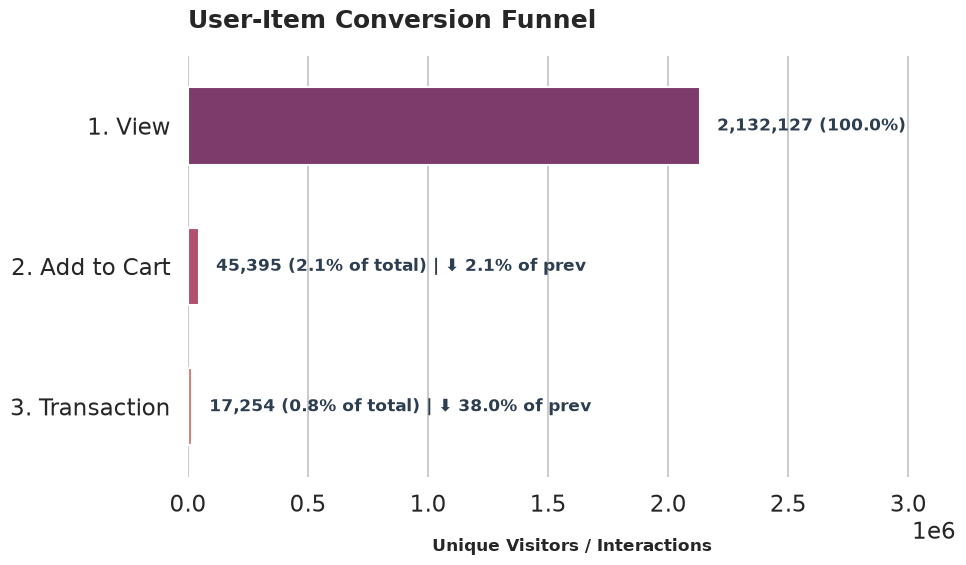

In [18]:
summary_data = funnel_summary.to_dicts()[0]
funnel_data = pd.DataFrame({
    "Stage": ["1. View", "2. Add to Cart", "3. Transaction"],
    "Count": [summary_data["views"], summary_data["carts"], summary_data["transactions"]]
})

total = funnel_data["Count"].iloc[0]
funnel_data["Pct_Total"] = (funnel_data["Count"] / total * 100).round(1)
funnel_data["Pct_Prev"] = (funnel_data["Count"] / funnel_data["Count"].shift(1).fillna(total) * 100).round(1)

sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(10, 6))

colors = sns.color_palette("flare_r", n_colors=len(funnel_data))
sns.barplot(
    data=funnel_data,
    x="Count",
    y="Stage",
    palette=colors,
    ax=ax,
    hue="Stage",
    legend=False,
    width=0.55
)

max_val = funnel_data["Count"].max()
for i, row in funnel_data.iterrows():
    count_val = row["Count"]
    pct_tot = row["Pct_Total"]
    pct_prv = row["Pct_Prev"]
    if i == 0:
        badge = f"  {count_val:,} ({pct_tot}%)"
    else:
        badge = f"  {count_val:,} ({pct_tot}% of total) | ⬇ {pct_prv}% of prev"
    ax.text(
        count_val + (max_val * 0.01),
        i,
        badge,
        va="center",
        ha="left",
        fontweight="semibold",
        fontsize=12,
        color="#2c3e50"
    )

ax.set_xlim(0, max_val * 1.5)  # Make room for the text badges
ax.set_xlabel("Unique Visitors / Interactions", fontsize=12, fontweight="bold", labelpad=15)
ax.set_ylabel("")
sns.despine(left=True, bottom=True)
plt.title("User-Item Conversion Funnel", fontsize=18, fontweight="bold", loc="left", pad=20)
plt.tight_layout()
plt.savefig(figure_path("user_item_level_funnel.png"), dpi=150, bbox_inches="tight")
plt.show()

### 3.2. Session-Based Funnel (30 mins session)

In [19]:
sessionized_df = (
    df_events.sort(["visitorid", "timestamp"])
    .with_columns(
        time_diff=pl.col("timestamp").diff().over("visitorid")
    )
    .with_columns(
        is_new_session=(
            pl.col("time_diff").is_null() |
            (pl.col("time_diff") > 1_800_000) # 30 min in milliseconds
        ).cast(pl.Int32)
    )
    .with_columns(
        session_id=pl.col("is_new_session").cum_sum().over("visitorid")
    )
    .collect()
)

session_funnel_steps = (
    sessionized_df.group_by(["visitorid", "session_id"])
    .agg(
        t_view=pl.col("timestamp").filter(pl.col("event") == "view").min(),
        t_cart=pl.col("timestamp").filter(pl.col("event") == "addtocart").min(),
        t_trans=pl.col("timestamp").filter(pl.col("event") == "transaction").min(),
    )
)

session_stages = session_funnel_steps.with_columns(
    step_1_view=pl.col("t_view").is_not_null(),
    step_2_cart=(
        pl.col("t_view").is_not_null() &
        pl.col("t_cart").is_not_null() &
        (pl.col("t_cart") >= pl.col("t_view"))
    ),
    step_3_transaction=(
        pl.col("t_view").is_not_null() &
        pl.col("t_cart").is_not_null() &
        pl.col("t_trans").is_not_null() &
        (pl.col("t_trans") >= pl.col("t_cart"))
    )
)

session_funnel_summary = (
    session_stages.select(
        total_sessions=pl.len(),
        sessions_with_views=pl.col("step_1_view").sum(),
        sessions_with_carts=pl.col("step_2_cart").sum(),
        sessions_with_transactions=pl.col("step_3_transaction").sum(),
    )
    .with_columns(
        view_to_cart_rate=pl.col("sessions_with_carts") / pl.col("sessions_with_views"),
        cart_to_trans_rate=pl.col("sessions_with_transactions") / pl.col("sessions_with_carts"),
        overall_conversion=pl.col("sessions_with_transactions") / pl.col("sessions_with_views")
    )
)

print(session_funnel_summary)

shape: (1, 7)
┌──────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ total_sessio ┆ sessions_wi ┆ sessions_wi ┆ sessions_wi ┆ view_to_car ┆ cart_to_tra ┆ overall_con │
│ ns           ┆ th_views    ┆ th_carts    ┆ th_transact ┆ t_rate      ┆ ns_rate     ┆ version     │
│ ---          ┆ ---         ┆ ---         ┆ ions        ┆ ---         ┆ ---         ┆ ---         │
│ u32          ┆ u32         ┆ u32         ┆ ---         ┆ f64         ┆ f64         ┆ f64         │
│              ┆             ┆             ┆ u32         ┆             ┆             ┆             │
╞══════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ 1761675      ┆ 1755781     ┆ 35832       ┆ 10983       ┆ 0.020408    ┆ 0.306514    ┆ 0.006255    │
└──────────────┴─────────────┴─────────────┴─────────────┴─────────────┴─────────────┴─────────────┘


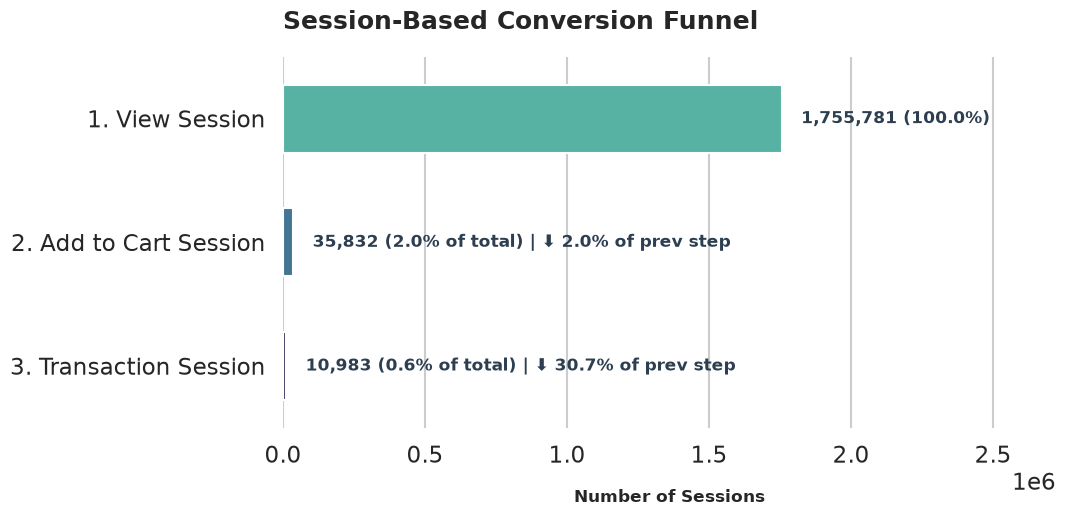

In [20]:
summary_data = session_funnel_summary.to_dicts()[0]
plot_data = pd.DataFrame({
    "Stage": ["1. View Session", "2. Add to Cart Session", "3. Transaction Session"],
    "Count": [summary_data["sessions_with_views"], summary_data["sessions_with_carts"], summary_data["sessions_with_transactions"]]
})

total_sessions_with_views = plot_data["Count"].iloc[0]
plot_data["Pct_Total"] = (plot_data["Count"] / total_sessions_with_views * 100).round(1)
plot_data["Pct_Prev"] = (plot_data["Count"] / plot_data["Count"].shift(1).fillna(total_sessions_with_views) * 100).round(1)

sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(11, 5.5))

colors = sns.color_palette("mako_r", n_colors=len(plot_data))
sns.barplot(
    data=plot_data,
    x="Count",
    y="Stage",
    palette=colors,
    ax=ax,
    hue="Stage",
    legend=False,
    width=0.55
)

max_val = plot_data["Count"].max()
for i, row in plot_data.iterrows():
    count_val = int(row["Count"])
    pct_tot = row["Pct_Total"]
    pct_prv = row["Pct_Prev"]
    if i == 0:
        badge = f"  {count_val:,} ({pct_tot}%)"
    else:
        badge = f"  {count_val:,} ({pct_tot}% of total) | ⬇ {pct_prv}% of prev step"
    ax.text(
        count_val + (max_val * 0.015),
        i,
        badge,
        va="center",
        ha="left",
        fontweight="semibold",
        fontsize=12,
        color="#2c3e50"
    )

ax.set_xlim(0, max_val * 1.55)  # Add buffer for text labels
ax.set_xlabel("Number of Sessions", fontsize=12, fontweight="bold", labelpad=15)
ax.set_ylabel("")
sns.despine(left=True, bottom=True)
plt.title("Session-Based Conversion Funnel", fontsize=18, fontweight="bold", loc="left", pad=20)
plt.tight_layout()
plt.savefig(figure_path("session_based_funnel.png"), dpi=150, bbox_inches="tight")
plt.show()

### 3.3. Key Diagnostic Insights

1. In both the simples User-Item-Level and the Session-Based funnels the transition rates and total rates are similar.
2. **~2%** items viewed lead to an item added to cart.
3. **~30%** of items added to cart lead to a transaction.

## 4. Temporal Dynamics & Validation Strategy

### 4.1. Seasonality Analysis

#### 4.1.1. Temporal Boundaries

In [21]:
boundaries = (
    df_events.with_columns(
        datetime=pl.col("timestamp").cast(pl.Datetime("ms"))
    ).select(
        min_time=pl.col("datetime").min(),
        max_time=pl.col("datetime").max(),
        total_days=(
            (pl.col("datetime").max() - pl.col("datetime").min()) / pl.duration(days=1)
        ).round(1)
    )
    .collect()
)
print("Dataset Temporal Boundaries:")
print(boundaries)

Dataset Temporal Boundaries:
shape: (1, 3)
┌─────────────────────────┬─────────────────────────┬────────────┐
│ min_time                ┆ max_time                ┆ total_days │
│ ---                     ┆ ---                     ┆ ---        │
│ datetime[ms]            ┆ datetime[ms]            ┆ f64        │
╞═════════════════════════╪═════════════════════════╪════════════╡
│ 2015-05-03 03:00:04.384 ┆ 2015-09-18 02:59:47.788 ┆ 138.0      │
└─────────────────────────┴─────────────────────────┴────────────┘


In [22]:
df_timeseries = (
    df_events.with_columns(
        datetime=pl.col("timestamp").cast(pl.Datetime("ms"))
    )
    # Ignoring first and last day to prevent outliers
    .filter((pl.col("datetime").dt.date() > pl.date(2015, 5, 3)) & (pl.col("datetime").dt.date() < pl.date(2015, 9, 18)))
    .collect()
)

#### 4.1.2. Seasonality and Spikes

In [23]:
# Daily volume (to detect daily trend spikes / platform issues)
daily_volume = (
    df_timeseries.group_by(pl.col("datetime").dt.date().alias("date"))
    .agg(
        total_interactions=pl.len(),
        purchases=pl.col("event").filter(pl.col("event") == "transaction").count()
    )
    .sort("date")
)
# Weekly/Hourly volume (to detect weekly and diurnal seasonality patterns)
hourly_profile = (
    df_timeseries.group_by(pl.col("datetime").dt.hour().alias("hour"))
    .len(name="interactions")
    .sort("hour")
)
weekday_profile = (
    df_timeseries.group_by(pl.col("datetime").dt.weekday().alias("weekday")) # 1 = Monday, 7 = Sunday
    .len(name="interactions")
    .sort("weekday")
)

iqr_bounds = daily_volume.select(
    q1=pl.col("total_interactions").quantile(0.25),
    q3=pl.col("total_interactions").quantile(0.75),
).with_columns(
    iqr=pl.col("q3") - pl.col("q1")
).with_columns(
    upper_fence=pl.col("q3") + 1.5 * pl.col("iqr"),
    lower_fence=pl.col("q1") - 1.5 * pl.col("iqr")
)
upper_fence = iqr_bounds["upper_fence"][0]
lower_fence = iqr_bounds["lower_fence"][0]

daily_outliers = daily_volume.with_columns(
    is_outlier=(
        (pl.col("total_interactions") > upper_fence) |
        (pl.col("total_interactions") < lower_fence)
    ),
    outlier_type=pl.when(pl.col("total_interactions") > upper_fence)
    .then(pl.lit("Unusual Spike (High)"))
    .when(pl.col("total_interactions") < lower_fence)
    .then(pl.lit("Unusual Drop (Low)"))
    .otherwise(pl.lit("Normal"))
)

print(f"Daily Volume Thresholds:\n  Upper Fence (Spike): {upper_fence:,.0f}\n  Lower Fence (Drop): {lower_fence:,.0f}")
print("\nDetected Unusual Outlier Days:")
print(daily_outliers.filter(pl.col("is_outlier")))

Daily Volume Thresholds:
  Upper Fence (Spike): 30,906
  Lower Fence (Drop): 8,618

Detected Unusual Outlier Days:
shape: (1, 5)
┌────────────┬────────────────────┬───────────┬────────────┬──────────────────────┐
│ date       ┆ total_interactions ┆ purchases ┆ is_outlier ┆ outlier_type         │
│ ---        ┆ ---                ┆ ---       ┆ ---        ┆ ---                  │
│ date       ┆ u32                ┆ u32       ┆ bool       ┆ str                  │
╞════════════╪════════════════════╪═══════════╪════════════╪══════════════════════╡
│ 2015-07-26 ┆ 32703              ┆ 144       ┆ true       ┆ Unusual Spike (High) │
└────────────┴────────────────────┴───────────┴────────────┴──────────────────────┘


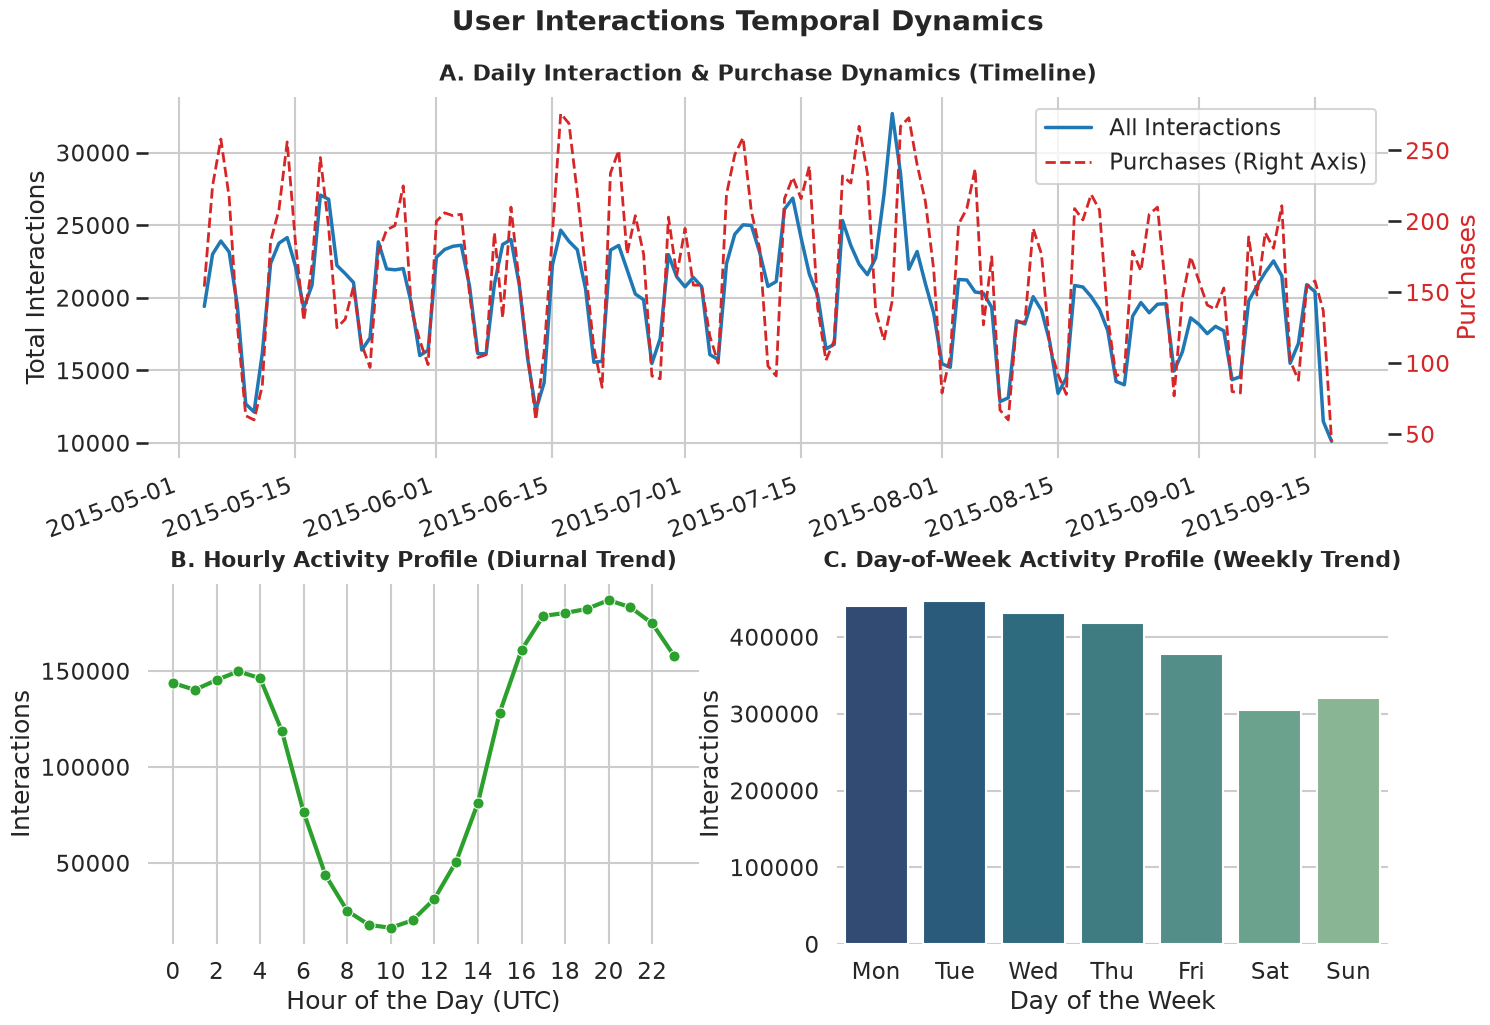

In [24]:
df_daily = daily_volume.to_pandas()
df_hourly = hourly_profile.to_pandas()
df_weekly = weekday_profile.to_pandas()
# Map weekday integers (1-7) to human-readable abbreviations
weekday_map = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}
df_weekly["weekday_name"] = df_weekly["weekday"].map(weekday_map)

sns.set_theme(style="whitegrid", context="talk", palette="mako")

fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.35, wspace=0.25)

ax1 = fig.add_subplot(gs[0, :])
sns.lineplot(
    data=df_daily,
    x="date",
    y="total_interactions",
    ax=ax1,
    color="#1f77b4",
    linewidth=2.5,
    label="All Interactions"
)

ax1_twin = ax1.twinx()
sns.lineplot(
    data=df_daily,
    x="date",
    y="purchases",
    ax=ax1_twin,
    color="#d62728",
    linewidth=2.0,
    linestyle="--",
    label="Purchases (Right Axis)"
)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.get_legend().remove() # Remove auto legend
ax1_twin.legend(lines + lines2, labels + labels2, loc="upper right", frameon=True)
ax1.set_title("A. Daily Interaction & Purchase Dynamics (Timeline)", fontsize=16, fontweight="bold", pad=12)
ax1.set_xlabel("")
ax1.set_ylabel("Total Interactions")
ax1_twin.set_ylabel("Purchases", color="#d62728")
ax1_twin.tick_params(axis='y', labelcolor="#d62728")
ax1_twin.grid(False) # Turn off secondary grid to avoid clashing
plt.setp(ax1.get_xticklabels(), rotation=20, ha="right")

ax2 = fig.add_subplot(gs[1, 0])
sns.lineplot(
    data=df_hourly,
    x="hour",
    y="interactions",
    ax=ax2,
    color="#2ca02c",
    linewidth=3,
    marker="o",
    markersize=8
)
ax2.set_title("B. Hourly Activity Profile (Diurnal Trend)", fontsize=16, fontweight="bold", pad=12)
ax2.set_xlabel("Hour of the Day (UTC)")
ax2.set_ylabel("Interactions")
ax2.set_xticks(range(0, 24, 2))

ax3 = fig.add_subplot(gs[1, 1])
sns.barplot(
    data=df_weekly,
    x="weekday_name",
    y="interactions",
    ax=ax3,
    palette="crest_r",
    hue="weekday_name",
    legend=False
)
ax3.set_title("C. Day-of-Week Activity Profile (Weekly Trend)", fontsize=16, fontweight="bold", pad=12)
ax3.set_xlabel("Day of the Week")
ax3.set_ylabel("Interactions")

sns.despine(left=True, bottom=True)
plt.suptitle("User Interactions Temporal Dynamics", fontsize=20, fontweight="bold", y=0.96)
plt.savefig(figure_path("temporal_dynamics_generic.png"), dpi=150, bbox_inches="tight")
plt.show()

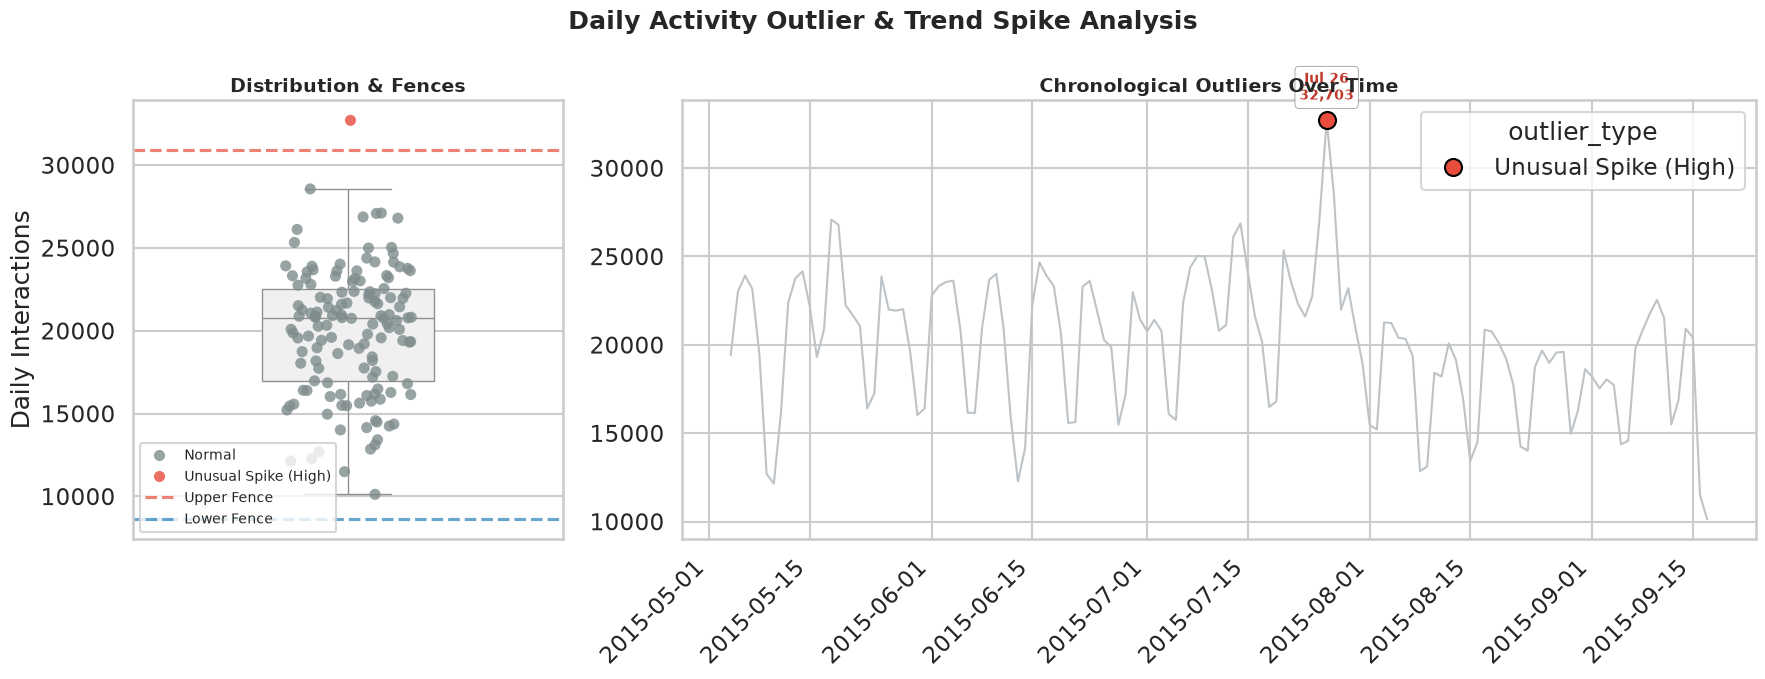

In [25]:
df_outliers = daily_outliers.to_pandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={"width_ratios": [1, 2.5]})
sns.set_theme(style="whitegrid", context="talk")

sns.boxplot(
    data=df_outliers,
    y="total_interactions",
    ax=ax1,
    color="#f0f0f0",
    width=0.4,
    fliersize=0
)

sns.stripplot(
    data=df_outliers,
    y="total_interactions",
    hue="outlier_type",
    palette={"Normal": "#7f8c8d", "Unusual Spike (High)": "#e74c3c", "Unusual Drop (Low)": "#2980b9"},
    alpha=0.8,
    size=8,
    ax=ax1,
    jitter=0.15
)
ax1.axhline(upper_fence, color="#e74c3c", linestyle="--", alpha=0.7, label="Upper Fence")
ax1.axhline(lower_fence, color="#2980b9", linestyle="--", alpha=0.7, label="Lower Fence")
ax1.set_title("Distribution & Fences", fontweight="bold", fontsize=14)
ax1.set_ylabel("Daily Interactions")
ax1.get_xaxis().set_visible(False)
ax1.legend(fontsize=10, loc="lower left")

sns.lineplot(
    data=df_outliers,
    x="date",
    y="total_interactions",
    ax=ax2,
    color="#bdc3c7",
    linewidth=1.5,
    zorder=1
)

sns.scatterplot(
    data=df_outliers[df_outliers["is_outlier"]],
    x="date",
    y="total_interactions",
    hue="outlier_type",
    palette={"Unusual Spike (High)": "#e74c3c", "Unusual Drop (Low)": "#2980b9"},
    s=150,
    edgecolor="black",
    linewidth=1.5,
    zorder=2,
    ax=ax2
)

for _, row in df_outliers[df_outliers["is_outlier"]].iterrows():
    ax2.annotate(
        f"{row['date'].strftime('%b %d')}\n{int(row['total_interactions']):,}",
        xy=(row["date"], row["total_interactions"]),
        xytext=(0, 15 if row["total_interactions"] > upper_fence else -25),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color="#c0392b" if row["total_interactions"] > upper_fence else "#2980b9",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", edgecolor="gray", alpha=0.9, lw=0.5)
    )

ax2.set_title("Chronological Outliers Over Time", fontweight="bold", fontsize=14)
ax2.set_xlabel("")
ax2.set_ylabel("")
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

plt.suptitle("Daily Activity Outlier & Trend Spike Analysis", fontsize=18, fontweight="bold", y=0.98)
plt.tight_layout()
plt.savefig(figure_path("temporal_dynamics_outliers.png"), dpi=150, bbox_inches="tight")
plt.show()

### 4.2. Leakage-Free Split Design

In [26]:
max_time = df_timeseries.select(pl.col("datetime").max()).item()

candidate_windows = [1, 2, 3, 5, 7, 10, 14, 21]
sweep_results = []

for days in candidate_windows:
    cutoff = max_time - pl.duration(days=days)
    # Split
    train_split = df_timeseries.filter(pl.col("datetime") < cutoff)
    test_candidates = df_timeseries.filter(pl.col("datetime") >= cutoff)
    # Get active users and items
    train_users = train_split.select("visitorid").unique()
    train_items = train_split.select("itemid").unique()
    # Apply overlap logic
    test_overlap = test_candidates.filter(
        pl.col("visitorid").is_in(train_users["visitorid"].implode()) &
        pl.col("itemid").is_in(train_items["itemid"].implode())
    )
    # Unique active users in the test set
    unique_test_users = test_overlap.select("visitorid").n_unique()
    sweep_results.append({
        "test_window_days": days,
        "raw_test_interactions": test_candidates.height,
        "cleaned_test_interactions": test_overlap.height,
        "data_retention_pct": round((test_overlap.height / test_candidates.height) * 100, 1),
        "unique_test_users": unique_test_users
    })

sweep_df = pl.DataFrame(sweep_results)
print("Temporal Validation Split Sweep Analysis:")
print(sweep_df)

Temporal Validation Split Sweep Analysis:
shape: (8, 5)
┌──────────────────┬───────────────────┬───────────────────┬───────────────────┬───────────────────┐
│ test_window_days ┆ raw_test_interact ┆ cleaned_test_inte ┆ data_retention_pc ┆ unique_test_users │
│ ---              ┆ ions              ┆ ractions          ┆ t                 ┆ ---               │
│ i64              ┆ ---               ┆ ---               ┆ ---               ┆ i64               │
│                  ┆ i64               ┆ i64               ┆ f64               ┆                   │
╞══════════════════╪═══════════════════╪═══════════════════╪═══════════════════╪═══════════════════╡
│ 1                ┆ 10129             ┆ 2599              ┆ 25.7              ┆ 1129              │
│ 2                ┆ 21624             ┆ 5480              ┆ 25.3              ┆ 1989              │
│ 3                ┆ 42050             ┆ 9719              ┆ 23.1              ┆ 3800              │
│ 5                ┆ 79822         

#### 4.2.1. Method 1: User Re-engagement Half-Life (Behavioral Anchoring)

The Logic: If the median user interacts with the platform every 4 days, then a 14-day test window is too long; most users from the training set will have already gone inactive, causing your 84% cold-start drop (`data_retention_pct=15.9` above).

The test window should be anchored to the 75th percentile of the User Inter-Arrival Time (the time elapsed between consecutive interactions of a user).

This guarantees that 75% of active training-set users are mathematically expected to return within the test window, minimizing test-set data loss while maximizing predictive utility.

In [27]:
# Compute the time difference between consecutive interactions per user
inter_arrival_df = (
    df_events.sort(["visitorid", "timestamp"])
    .with_columns(
        time_diff_days=(
            pl.col("timestamp").diff().over("visitorid") / (1000 * 60 * 60 * 24)
        )
    )
    .filter(pl.col("time_diff_days").is_not_null())
    .collect()
)

# Extract percentiles
stats = inter_arrival_df.select(
    p50_days=pl.col("time_diff_days").quantile(0.50),  # Median return time
    p75_days=pl.col("time_diff_days").quantile(0.75),  # 75% of users return within this
    p90_days=pl.col("time_diff_days").quantile(0.90)
)
print("User Inter-Arrival Time Distribution (Days):")
print(stats)

User Inter-Arrival Time Distribution (Days):
shape: (1, 3)
┌──────────┬──────────┬──────────┐
│ p50_days ┆ p75_days ┆ p90_days │
│ ---      ┆ ---      ┆ ---      │
│ f64      ┆ f64      ┆ f64      │
╞══════════╪══════════╪══════════╡
│ 0.001579 ┆ 0.028354 ┆ 3.050044 │
└──────────┴──────────┴──────────┘


#### 4.2.2. Method 2: Mathematical Knee/Elbow Detection (Optimization)

The Logic: Run a daily sweep and calculate the rate of change (first derivative) of the test set retention curve. We find the "Knee" (inflection point) where adding another day to the test window yields diminishing returns (massive drop in data retention vs. minimal gain in raw test volume).

In [28]:
max_time = df_timeseries.select(pl.col("datetime").max()).item()

# 1. Sweep day-by-day up to 21 days
daily_sweep = []
for days in range(1, 22):
    cutoff = max_time - pl.duration(days=days)
    train_split = df_timeseries.filter(pl.col("datetime") < cutoff)
    test_candidates = df_timeseries.filter(pl.col("datetime") >= cutoff)
    train_users = train_split.select("visitorid").unique()
    train_items = train_split.select("itemid").unique()
    test_overlap = test_candidates.filter(
        pl.col("visitorid").is_in(train_users["visitorid"].implode()) &
        pl.col("itemid").is_in(train_items["itemid"].implode())
    )
    daily_sweep.append({
        "days": days,
        "cleaned_volume": test_overlap.height,
        "retention_pct": test_overlap.height / test_candidates.height
    })
sweep_df = pl.DataFrame(daily_sweep)

# 2. Find the optimal knee using the standard vector projection method (Kneedle algorithm logic)
# We find the point furthest from the straight line connecting the first and last points of the sweep.
coords = sweep_df.select(["days", "retention_pct"]).to_numpy()
first_pt = coords[0]
last_pt = coords[-1]
line_vec = last_pt - first_pt
line_vec_norm = line_vec / np.sqrt(np.sum(line_vec**2))
distances = []
for p in coords:
    pt_vec = p - first_pt
    proj_len = np.dot(pt_vec, line_vec_norm)
    proj_pt = first_pt + proj_len * line_vec_norm
    dist = np.sqrt(np.sum((p - proj_pt)**2))
    distances.append(dist)
optimal_days = sweep_df["days"][int(np.argmax(distances))]
print(f"Mathematical Optimal Test Window (Knee Point): {optimal_days} days")

Mathematical Optimal Test Window (Knee Point): 6 days


#### 4.2.3. Method 3: Time-Series Walk-Forward Cross-Validation (Production Rigor)

The Logic: Instead of locking the architecture to a single arbitrary window, production pipelines use a rolling validation fold framework.
You validate across multiple non-overlapping sliding windows to verify model stability over time.

In [29]:
# Create 3 evaluation folds, each using 14 days of training history to predict 2 days of testing
fold_specs = [
    {"fold": 1, "test_start_offset_days": 2, "test_duration_days": 2},
    {"fold": 2, "test_start_offset_days": 4, "test_duration_days": 2},
    {"fold": 3, "test_start_offset_days": 6, "test_duration_days": 2},
]
for spec in fold_specs:
    # Use native Python timedelta for datetime math
    test_start = max_time - datetime.timedelta(days=spec["test_start_offset_days"])
    test_end = test_start + datetime.timedelta(days=spec["test_duration_days"])
    train_start = test_start - datetime.timedelta(days=14) # Standardized 14-day training window
    # Filter using Python datetimes
    train_fold = df_timeseries.filter((pl.col("datetime") >= train_start) & (pl.col("datetime") < test_start))
    test_fold_raw = df_timeseries.filter((pl.col("datetime") >= test_start) & (pl.col("datetime") < test_end))
    # Restrict to active users and items in train fold
    train_users = train_fold.select("visitorid").unique()
    train_items = train_fold.select("itemid").unique()
    test_fold_clean = test_fold_raw.filter(
        pl.col("visitorid").is_in(train_users["visitorid"].implode()) &
        pl.col("itemid").is_in(train_items["itemid"].implode())
    )
    print(f"Fold {spec['fold']} (Test Period: {test_start.date()} to {test_end.date()}):")
    print(f"  Train: {train_fold.height:,} interactions")
    print(f"  Test (Cleaned): {test_fold_clean.height:,} interactions (Retention: {test_fold_clean.height/test_fold_raw.height:.1%})")

Fold 1 (Test Period: 2015-09-15 to 2015-09-17):
  Train: 262,380 interactions
  Test (Cleaned): 3,530 interactions (Retention: 16.3%)
Fold 2 (Test Period: 2015-09-13 to 2015-09-15):
  Train: 257,844 interactions
  Test (Cleaned): 5,609 interactions (Retention: 13.6%)
Fold 3 (Test Period: 2015-09-11 to 2015-09-13):
  Train: 256,736 interactions
  Test (Cleaned): 3,755 interactions (Retention: 11.6%)


### 4.3. Key Diagnostic Insights

Method 1: The Behavior Shock (Inter-Arrival Time)
- **The Data:** Median return time is ~2.2 minutes ($0.001579$ days), 75% of returns happen within ~40 minutes ($0.028354$ days), and only 10% of returns take longer than 3 days.
- **The Diagnostic:** users do not have long-term cross-session loyalty on this platform. This behavior is typical of anonymous guest traffic, fast-purchasing e-commerce sites, or a platform with highly localized, session-bound intents.
- **The Impact on Modeling:** Traditional collaborative filtering (which relies on static, long-term user profiles) will fail here because users are transient. The recommendation model must be sequential or session-based (e.g., Word2Vec/Item2Vec, GRU4Rec, or SASRec).

Method 2: The Global Compromise (Knee Point)
- **The Data:** Math detects the optimal static test window at 6 days.
- **The Diagnostic:** If we must use a single, static train/test split, 6 days is the mathematical sweet spot. Any shorter, and our test set is too small/noisy; any longer, and the vocabulary decay (cold-start drop-off) ruins our validation metrics.

Method 3: Walk-Forward Cross-Validation (The Reality Check)
- **The Data:** Truncating training to a 14-day rolling window yields ~260k interactions, but results in a brutal 11.5% to 16.2% test retention.
- **The Diagnostic:** Although it preserves ~3.5k to 5.5k clean test interactions (statistically sufficient for ranking metrics), it discards over 80% of test interactions because either the user or the item did not appear in that specific 14-day training slice.

---

How Embedding Vector Training Suffers Under Method 3

Training user/item embedding vectors (e.g., Matrix Factorization, Neural Collaborative Filtering, or sequential models) directly inside a rolling window framework, will encounter three severe architectural bottlenecks:

1. **Extreme Data Starvation (Sparsity Death):** The total dataset has 2.75 Million interactions, but a rolling fold limits training to only ~260k interactions (10% of the data). Embeddings need high-frequency co-occurrence to converge. Cutting the training data by 90% means sparse items will have completely un-optimized, noisy embedding vectors, leading to terrible recommendation quality.
2. **Coordinate Space Drift (Index Alignment Problem):** Training a new model from scratch for Fold 1, Fold 2, and Fold 3, will cause the embedding spaces to be completely unaligned. Item A might end up at coordinate $[0.1, -0.9]$ in Fold 1 and $[-0.5, 0.4]$ in Fold 2 due to random initialization and training shifts. It is not possible to safely compare or reuse these models without complex alignment phases (Procrustes alignment).
3. **User Representation Collapse:** Since 90% of user returns happen in under 3 days, a user's embedding vector trained in a 14-day window will be completely useless for a test window 2 days later because the user has already left the platform.

---

Professional ML Architecture Recommendation

To get the mathematical rigor of Method 3 without destroying the embedding quality, a Two-Tier Training & Validation
Architecture can be used.

```text
1 [ Tier 1: Representation Learning ] (Heavy, Global, Static)
2   - Train on ALL 2.75M interactions.
3   - Learn high-fidelity Item Embeddings (e.g., Item2Vec, DSSM, or Autoencoders).
4   - Freeze these embeddings.
5          │
6          ▼ (Frozen Vectors)
7 [ Tier 2: Sequence / Session Model ] (Lightweight, Rolling/Online)
8   - Train sequential/session dynamics (e.g., Session-GRU, attention layers, or KNN rules).
9   - Use Method 3 (Walk-Forward CV) on this layer only.
```

Step-by-Step Implementation Strategy:

**Step 1:** Learn Static Item Representations (No Cold Start)
- Use the entire 2.75M dataset to train Item Embeddings (ignoring user identities, just focusing on item-to-item chronological transitions across the entire timeline). Since items don't "go anonymous," item embeddings will be incredibly rich and well-trained.
- Once trained, freeze the Item Embedding weights.

**Step 2:** Model Users Dynamically (Session-Based)
- Instead of learning a User Embedding Lookup Table (which fails for anonymous/transient users), represent a user dynamically as the average or attention-weighted sum of their last N interacted item embeddings.
- This bypasses the user cold-start problem completely. If a user returns in the test set, as long as they have viewed at least one item in their active session, you can immediately recommend items using your frozen item vectors.

**Step 3:** Validate via Walk-Forward Folds (Method 3)
- Evaluate the sequential aggregator (e.g., "Given the current session's item vectors, can we predict the next item?") using the rolling folds of Method 3.
- This preserves production validation accuracy (no leakage) while ensuring your underlying vectors are fully optimized using the entire dataset's volume.

## 5. Metadata Enrichment & Taxonomy Alignment

In [30]:
prop_part1 = pl.scan_csv(item_properties_part1_path)
prop_part2 = pl.scan_csv(item_properties_part2_path)
# Vertical concatenation of properties
properties_lazy = pl.concat([prop_part1, prop_part2])

### 5.1. Dynamic vs. Static Attribute Analysis

Goal: Isolate property keys that are static (fixed per item) from those that are dynamic (e.g., changes in price, stock, or "available" flag over time).

In [31]:
# A. Group by item and property to find update frequency and cardinality per item
item_prop_cardinality = (
    properties_lazy
    .group_by(["itemid", "property"])
    .agg(
        num_updates=pl.len(),
        num_unique_values=pl.col("value").n_unique()
    )
)
# B. Aggregate at the global Property level to determine dynamic nature
property_classification = (
    item_prop_cardinality
    .group_by("property")
    .agg(
        total_items_linked=pl.col("itemid").n_unique(),
        avg_updates_per_item=pl.col("num_updates").mean(),
        # Ratio of items where this property changes value over time
        pct_items_with_value_changes=(
            pl.col("num_unique_values").gt(1).sum() / pl.col("itemid").count() * 100
        )
    )
    .with_columns(
        is_dynamic=pl.col("pct_items_with_value_changes") > 0.0
    )
    .sort("pct_items_with_value_changes", descending=True)
    .collect() # Trigger optimized computation graph
)
# Isolate classifications
dynamic_props = property_classification.filter(pl.col("is_dynamic"))
static_props = property_classification.filter(~pl.col("is_dynamic"))
print("Dynamic Properties (Value changes over time for same item):")
print(dynamic_props.head(10))
print("\nStatic Properties (Constant values per item):")
print(static_props.head(10))

Dynamic Properties (Value changes over time for same item):
shape: (10, 5)
┌──────────┬────────────────────┬──────────────────────┬──────────────────────────────┬────────────┐
│ property ┆ total_items_linked ┆ avg_updates_per_item ┆ pct_items_with_value_changes ┆ is_dynamic │
│ ---      ┆ ---                ┆ ---                  ┆ ---                          ┆ ---        │
│ str      ┆ u32                ┆ f64                  ┆ f64                          ┆ bool       │
╞══════════╪════════════════════╪══════════════════════╪══════════════════════════════╪════════════╡
│ 25       ┆ 216                ┆ 22.814815            ┆ 85.185185                    ┆ true       │
│ 1075     ┆ 214                ┆ 25.037383            ┆ 83.17757                     ┆ true       │
│ 61       ┆ 1622               ┆ 21.918619            ┆ 76.140567                    ┆ true       │
│ 962      ┆ 12316              ┆ 20.944462            ┆ 72.060734                    ┆ true       │
│ 490      ┆ 197

### 5.2. Taxonomy Depth Mapping (Iterative Hierarchical Traversal)

Goal: Measure the depth of the category tree in category_tree.csv. Because category_tree represents a graph (parent-child), we traverse upwards iteratively using self-joins to find the exact level of every category.

In [32]:
category_tree = pl.read_csv(category_tree_path)
# Initialize path tracking DataFrame
# Every category starts at depth 0, tracking its current parent pointer
paths = category_tree.select([
    pl.col("categoryid"),
    pl.col("parentid").alias("current_parent"),
    pl.lit(0).alias("depth")
])
max_expected_depth = 20
for i in range(1, max_expected_depth + 1):
    # Join current parent with category ids to resolve grand-parents
    joined = paths.join(
        category_tree,
        left_on="current_parent",
        right_on="categoryid",
        how="left"
    ).select([
        pl.col("categoryid"),
        # Next parent is parent of current_parent, or null if root is reached
        pl.col("parentid").alias("next_parent"),
        # Increment depth ONLY if the current parent was not null (still climbing the tree)
        pl.when(pl.col("current_parent").is_not_null())
        .then(pl.col("depth") + 1)
        .otherwise(pl.col("depth"))
        .alias("depth")
    ])
    # Check if any categories still have parents left to climb
    active_climbers = joined.filter(pl.col("next_parent").is_not_null()).height
    paths = joined.rename({"next_parent": "current_parent"})
    if active_climbers == 0:
        break
# Compute Taxonomy Statistics
taxonomy_summary = paths.select([
    pl.col("depth").max().alias("max_depth"),
    pl.col("depth").mean().round(2).alias("avg_depth"),
    pl.col("depth").median().alias("median_depth"),
])
# Distribution of categories across each depth tier
depth_distribution = (
    paths.group_by("depth")
    .agg(
        num_categories=pl.len(),
        pct_of_total=(pl.len() / paths.height * 100).round(2)
    )
    .sort("depth")
)
print("\nCategory Tree Taxonomy Depth Summary:")
print(taxonomy_summary)
print("\nCategory Distribution by Depth Level (Tier):")
print(depth_distribution)


Category Tree Taxonomy Depth Summary:
shape: (1, 3)
┌───────────┬───────────┬──────────────┐
│ max_depth ┆ avg_depth ┆ median_depth │
│ ---       ┆ ---       ┆ ---          │
│ i32       ┆ f64       ┆ f64          │
╞═══════════╪═══════════╪══════════════╡
│ 5         ┆ 2.4       ┆ 2.0          │
└───────────┴───────────┴──────────────┘

Category Distribution by Depth Level (Tier):
shape: (6, 3)
┌───────┬────────────────┬──────────────┐
│ depth ┆ num_categories ┆ pct_of_total │
│ ---   ┆ ---            ┆ ---          │
│ i32   ┆ u32            ┆ f64          │
╞═══════╪════════════════╪══════════════╡
│ 0     ┆ 25             ┆ 1.5          │
│ 1     ┆ 174            ┆ 10.43        │
│ 2     ┆ 702            ┆ 42.06        │
│ 3     ┆ 665            ┆ 39.84        │
│ 4     ┆ 90             ┆ 5.39         │
│ 5     ┆ 13             ┆ 0.78         │
└───────┴────────────────┴──────────────┘


## 6. Preprocessing & Filtering Rules (Pruning Criteria)

In [33]:
# --- Setup Thresholds (Determined statistically below) ---
MIN_USER_INTERACTIONS = 5  # Standard threshold to solve sparse user history
MIN_ITEM_EXPOSURE = 5      # Prevent ungeneralizable/rare item embeddings
BOT_ACTIVITY_THRESHOLD = 500  # Visitors with suspicious/automated request rates

df = df_events.collect()

In [34]:
# =====================================================================
# 1. Establish Baselines & Statistical Distributions
# =====================================================================
# Read raw interactions (assuming your core events dataframe is ready)
print(f"Raw dataset interaction rows: {df.height:,}")
print(f"Raw unique visitors: {df["visitorid"].n_unique():,}")
print(f"Raw unique items: {df["itemid"].n_unique():,}")
# Calculate total interactions per user
user_counts = df.group_by("visitorid").len(name="user_activity")
# Calculate total interactions per item
item_counts = df.group_by("itemid").len(name="item_exposure")

Raw dataset interaction rows: 2,756,101
Raw unique visitors: 1,407,580
Raw unique items: 235,061


In [35]:
# =====================================================================
# 2. Identify Systemic Outliers (Suspicious Automated Bots)
# =====================================================================
# Find extreme bot-like users (e.g., visitors generating thousands of views in a few hours)
bots = user_counts.filter(pl.col("user_activity") > BOT_ACTIVITY_THRESHOLD)
print(f"\nSuspicious Bot Detection:")
print(f"-> Found {bots.height:,} visitors with > {BOT_ACTIVITY_THRESHOLD} interactions.")
print(f"-> Bot interactions to prune: {bots.select(pl.col('user_activity').sum()).item():,}")


Suspicious Bot Detection:
-> Found 75 visitors with > 500 interactions.
-> Bot interactions to prune: 93,063


In [36]:
# =====================================================================
# 3. Apply Multi-Stage Pruning Filter
# =====================================================================
# We execute this pipeline in a single, high-speed logical step
clean_df = (
    df
    # A. Join user and item activity counts
    .join(user_counts, on="visitorid", how="left")
    .join(item_counts, on="itemid", how="left")
    # B. Apply multi-stage constraints
    .filter(
        # Rule 1: Exclude automated scraping bots
        (pl.col("user_activity") <= BOT_ACTIVITY_THRESHOLD) &
        # Rule 2: Exclude users with sparse/insufficient signal
        (pl.col("user_activity") >= MIN_USER_INTERACTIONS) &
        # Rule 3: Exclude items with insufficient exposure
        (pl.col("item_exposure") >= MIN_ITEM_EXPOSURE)
    )
    # C. Drop auxiliary activity count columns to match raw schema
    .drop(["user_activity", "item_exposure"])
)

print("======================================== ORIGINAL DF =========================================")
print(df.describe())
print("======================================== CLEAN DF ============================================")
print(clean_df.describe())

======================================== ORIGINAL DF =========================================
shape: (9, 6)
┌────────────┬────────────┬───────────────┬───────────┬───────────────┬───────────────┐
│ statistic  ┆ timestamp  ┆ visitorid     ┆ event     ┆ itemid        ┆ transactionid │
│ ---        ┆ ---        ┆ ---           ┆ ---       ┆ ---           ┆ ---           │
│ str        ┆ f64        ┆ f64           ┆ str       ┆ f64           ┆ str           │
╞════════════╪════════════╪═══════════════╪═══════════╪═══════════════╪═══════════════╡
│ count      ┆ 2.756101e6 ┆ 2.756101e6    ┆ 2756101   ┆ 2.756101e6    ┆ 22457         │
│ null_count ┆ 0.0        ┆ 0.0           ┆ 0         ┆ 0.0           ┆ 2733644       │
│ mean       ┆ 1.4364e12  ┆ 701922.883229 ┆ null      ┆ 234922.478375 ┆ null          │
│ std        ┆ 3.3663e9   ┆ 405687.520809 ┆ null      ┆ 134195.425214 ┆ null          │
│ min        ┆ 1.4306e12  ┆ 0.0           ┆ addtocart ┆ 3.0           ┆ 0             │
│ 25%      

In [37]:
# =====================================================================
# 4. Interactive Core Density Check (2-Core Diagnostics)
# =====================================================================
# Since removing a sparse user might cause an item's count to drop below the threshold
# (and vice versa), high-quality pipelines evaluate the final density:
clean_user_counts = clean_df.group_by("visitorid").len(name="user_activity")
clean_item_counts = clean_df.group_by("itemid").len(name="item_exposure")
min_user_act = clean_user_counts["user_activity"].min()
min_item_exp = clean_item_counts["item_exposure"].min()
print(f"\nPruned Dataset Summary (Min User Act: {MIN_USER_INTERACTIONS}, Min Item Exp: {MIN_ITEM_EXPOSURE}):")
print(f"-> Clean interaction rows: {clean_df.height:,} ({clean_df.height / df.height:.1%} of raw rows preserved)")
print(f"-> Clean unique visitors: {clean_df['visitorid'].n_unique():,} ({clean_df['visitorid'].n_unique() /
df['visitorid'].n_unique():.1%})")
print(f"-> Clean unique items: {clean_df['itemid'].n_unique():,} ({clean_df['itemid'].n_unique() / df['itemid'].n_unique():.1%})")
print(f"-> Verified core constraints:")
print(f"   - Minimum user interactions in clean set: {min_user_act}")
print(f"   - Minimum item exposure in clean set: {min_item_exp}")


Pruned Dataset Summary (Min User Act: 5, Min Item Exp: 5):
-> Clean interaction rows: 809,801 (29.4% of raw rows preserved)
-> Clean unique visitors: 81,243 (5.8%)
-> Clean unique items: 66,622 (28.3%)
-> Verified core constraints:
   - Minimum user interactions in clean set: 1
   - Minimum item exposure in clean set: 1
